# Assignment 1 M1 — Fashion-MNIST EDA and training pipeline

**Task.** Classify one 28 × 28 grayscale clothing image into one of 10 classes. Fashion-MNIST is the main comparison dataset; MNIST may be used only for debugging. The M1 code uses seed 42 and a stratified 54,000/6,000 train/validation split. The official 10,000-image test set remains held out.

**Dataset provenance.** Fashion-MNIST is a Zalando article-image dataset with 60,000 official training and 10,000 official test images, 10 labels, and 28 × 28 grayscale pixels. The source repository lists an MIT license. We use `torchvision.datasets.FashionMNIST`; no separate dataset version tag is supplied by torchvision. The reusable loader records a SHA-256 of the raw training images and labels. [Dataset repository](https://github.com/zalandoresearch/fashion-mnist) · [Torchvision loader](https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html)

**M1 scope.** The notebook covers class distribution, input size, imbalance, representative samples, split and leakage checks, normalization, a processed batch, and reproducible training and validation for Linear and MLP classifiers. The reusable code is in `a1/`; the run configuration is `configs/m1.json`.

In [1]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, Subset

from a1.data import (
    DATA_DIR, NUM_CLASSES, SEED, VAL_RATIO, FashionMNISTView,
    build_dataloaders, compute_normalization_stats, load_raw_datasets,
    stratified_train_val_split, to_representation,
)


## 1. Load and validate raw data

The official test set stays held out. All exploratory image statistics, class counts, and example images below come from the official training partition. Only the official test sample count is noted; its pixels and labels are not inspected in M1.

In [2]:
import hashlib
from pathlib import Path

import matplotlib.pyplot as plt
import torchvision

train_full, test_set = load_raw_datasets(DATA_DIR)
train_images = train_full.data.numpy()
train_labels = train_full.targets.numpy()
class_names = train_full.classes

assert train_images.shape[1:] == (28, 28)
assert train_images.dtype == np.uint8
assert len(class_names) == NUM_CLASSES
assert np.isin(train_labels, np.arange(NUM_CLASSES)).all()
assert len(train_images) == len(train_labels) == 60_000
assert len(test_set) == 10_000

print(f"Source: torchvision {torchvision.__version__}; Fashion-MNIST official split")
print(f"Official train: {len(train_full):,}; official test: {len(test_set):,} (count only)")
print(f"Raw training-image shape: {train_images.shape[1:]}; channels: 1; dtype: {train_images.dtype}")
print(f"Raw training-pixel range: {train_images.min()}–{train_images.max()}")
print(f"Uncompressed training-image array: {train_images.nbytes/2**20:.1f} MiB (labels excluded)")
raw_dir = Path(DATA_DIR) / 'FashionMNIST' / 'raw'
for f in sorted(raw_dir.glob('train-*')):
    if f.is_file():
        print(f"Disk: {f.name}: {f.stat().st_size/2**20:.2f} MiB")

Source: torchvision 0.29.0; Fashion-MNIST official split
Official train: 60,000; official test: 10,000 (count only)
Raw training-image shape: (28, 28); channels: 1; dtype: uint8
Raw training-pixel range: 0–255
Uncompressed training-image array: 44.9 MiB (labels excluded)
Disk: train-images-idx3-ubyte: 44.86 MiB
Disk: train-images-idx3-ubyte.gz: 25.20 MiB
Disk: train-labels-idx1-ubyte: 0.06 MiB
Disk: train-labels-idx1-ubyte.gz: 0.03 MiB


## 2. Reproduce the shared split and inspect class balance

Split the 60,000 official training examples into 54,000 train and 6,000 validation examples with `SEED=42`, `VAL_RATIO=0.10`, and stratification by class. The 10,000 official test examples remain untouched. The same index arrays can be reused for the later M2 model comparison.

,Train,Validation
Class,,
T-shirt/top,5400,600
Trouser,5400,600
Pullover,5400,600
Dress,5400,600
Coat,5400,600
Sandal,5400,600
Shirt,5400,600
Sneaker,5400,600
Bag,5400,600


Train: n=54,000, min=5,400, max=5,400, max/min=1.000, majority=10.0%
Validation: n=6,000, min=600, max=600, max/min=1.000, majority=10.0%


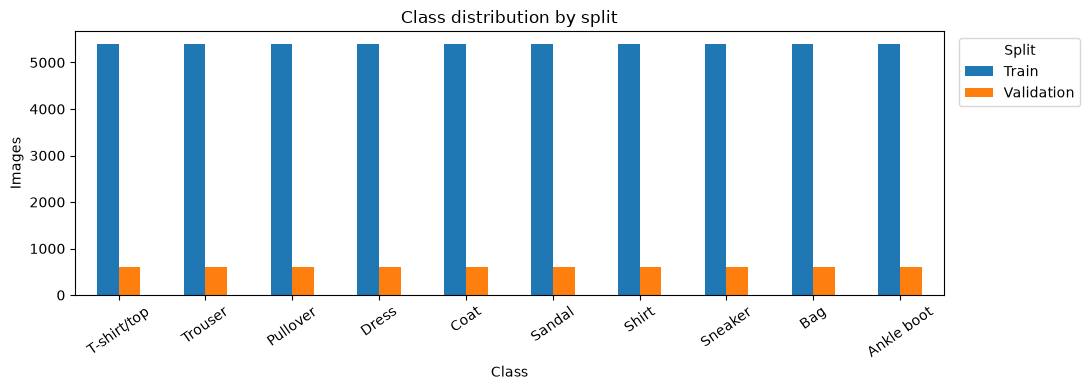

In [3]:
train_idx, val_idx = stratified_train_val_split(train_labels, VAL_RATIO, SEED)
assert len(set(train_idx) & set(val_idx)) == 0
assert len(train_idx) + len(val_idx) == len(train_full)

split_labels = {'Train': train_labels[train_idx], 'Validation': train_labels[val_idx]}
counts = pd.DataFrame({name: np.bincount(y, minlength=NUM_CLASSES) for name, y in split_labels.items()}, index=class_names)
counts.index.name = 'Class'
display(counts)
for name, y in split_labels.items():
    freq = np.bincount(y, minlength=NUM_CLASSES)
    print(f"{name}: n={len(y):,}, min={freq.min():,}, max={freq.max():,}, max/min={freq.max()/freq.min():.3f}, majority={freq.max()/len(y):.1%}")

ax = counts.plot.bar(figsize=(11, 4), rot=35)
ax.set(title='Class distribution by split', ylabel='Images', xlabel='Class')
ax.legend(title='Split', loc='upper left', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

**Interpretation.** A max/min class count ratio of 1.00 means perfect balance. If the observed ratio differs, report its size and decide whether class weighting or resampling is justified. Stratification preserves class proportions in train and validation. The index intersection check prevents a sample index appearing in both subsets. The official test partition is loaded separately but its contents are not inspected in M1.

## 3. Representative images and pixel characteristics

Show one reproducibly selected training example per class. These examples illustrate the small, grayscale inputs and potential visual ambiguity among similar garments; they are not model predictions.

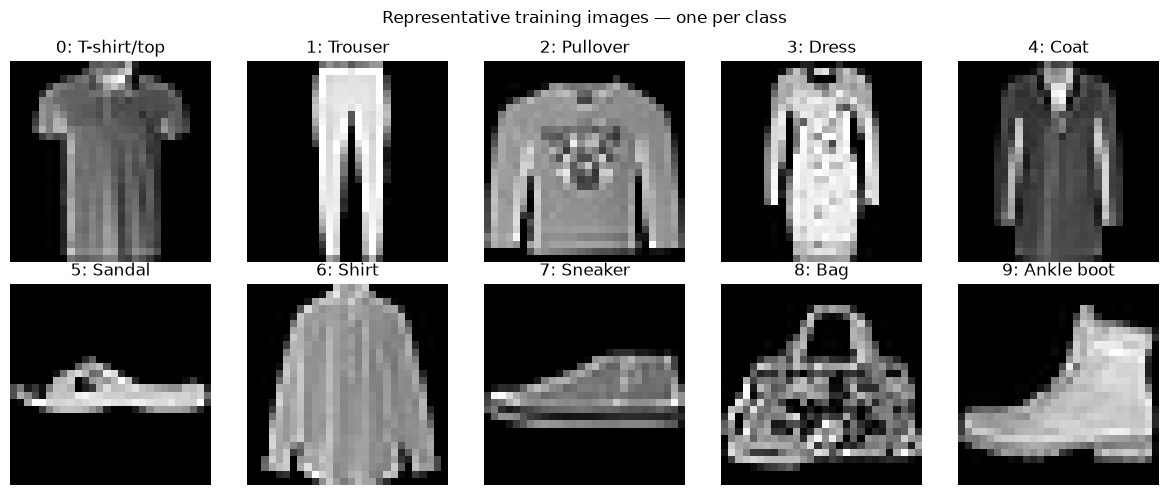

Training pixels: min=0, max=255, mean=72.98, std=90.06 on 0–255 scale
Zero-valued training pixels: 50.2%


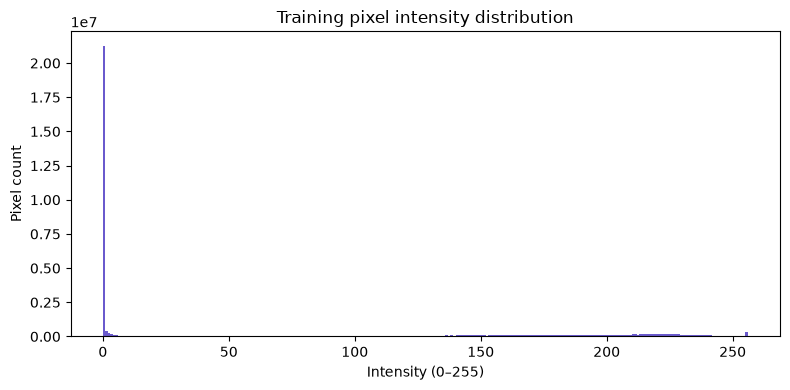

In [4]:
rng = np.random.default_rng(SEED)
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for label, ax in enumerate(axes.flat):
    candidate_idx = train_idx[train_labels[train_idx] == label]
    image = train_images[rng.choice(candidate_idx)]
    ax.imshow(image, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'{label}: {class_names[label]}')
    ax.axis('off')
fig.suptitle('Representative training images — one per class')
plt.tight_layout()
plt.show()

pixels = train_images[train_idx]
print(f'Training pixels: min={pixels.min()}, max={pixels.max()}, mean={pixels.mean():.2f}, std={pixels.std():.2f} on 0–255 scale')
print(f'Zero-valued training pixels: {(pixels == 0).mean():.1%}')
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(pixels.ravel(), bins=np.arange(257), color='slateblue')
ax.set(title='Training pixel intensity distribution', xlabel='Intensity (0–255)', ylabel='Pixel count')
plt.tight_layout()
plt.show()

## 4. Additional training-set EDA: image density and class prototypes

Brightness and foreground coverage can reveal class-specific visual patterns or preprocessing problems. Here, foreground means a raw pixel value greater than zero; it is a simple descriptive measure, not a segmentation label. Class-average images show the broad silhouette, while individual examples show variation that averages can hide.

Mean pixel intensity         Foreground fraction       
                            mean     std                mean    std
Class                                                              
T-shirt/top               83.023  28.839               0.594  0.076
Trouser                   56.906  14.556               0.349  0.070
Pullover                  96.168  32.700               0.648  0.071
Dress                     65.914  21.332               0.427  0.093
Coat                      98.147  26.466               0.602  0.075
Sandal                    34.872  15.739               0.321  0.104
Shirt                     84.839  32.904               0.629  0.079
Sneaker                   42.813  12.849               0.338  0.054
Bag                       90.281  28.811               0.586  0.114
Ankle boot                76.870  18.325               0.485  0.075

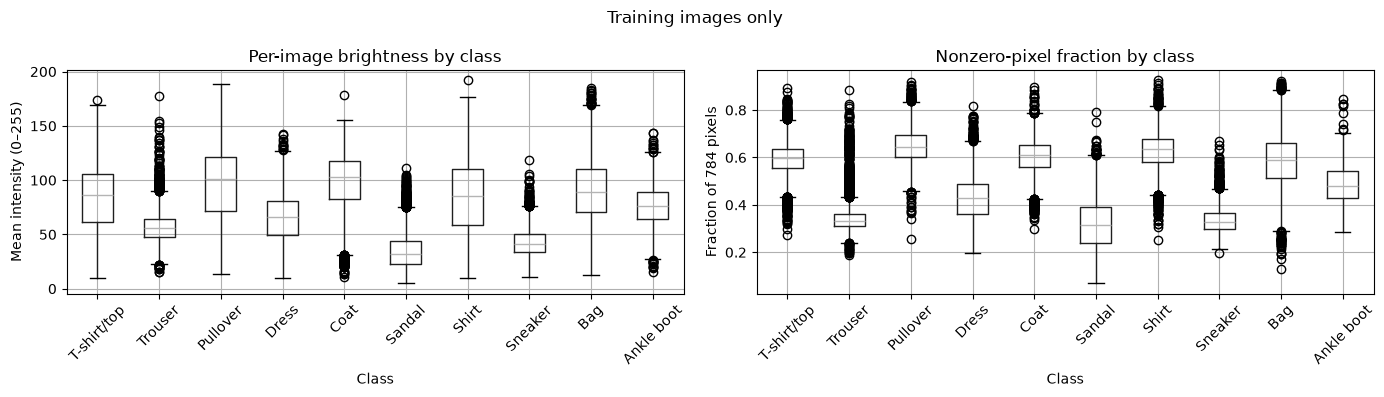

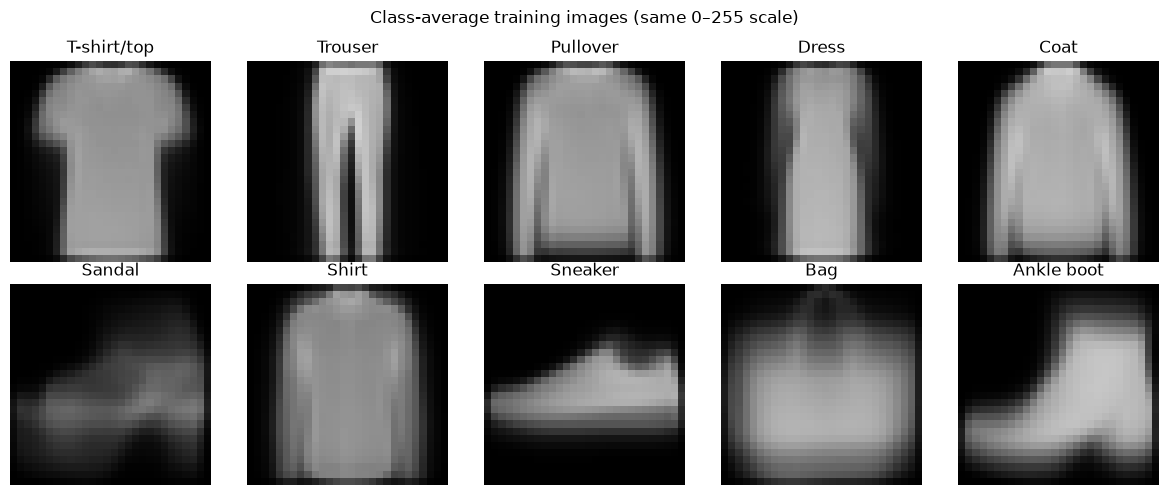

All-zero training images: 0


In [5]:
train_pixels = train_images[train_idx]
train_y = train_labels[train_idx]
mean_intensity = train_pixels.mean(axis=(1, 2))
foreground_fraction = (train_pixels > 0).mean(axis=(1, 2))
summary = pd.DataFrame({
    'Class': [class_names[i] for i in train_y],
    'Mean pixel intensity': mean_intensity,
    'Foreground fraction': foreground_fraction,
})
summary['Class'] = pd.Categorical(summary['Class'], categories=class_names, ordered=True)
display(summary.groupby('Class', observed=True).agg(['mean', 'std']).round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
summary.boxplot(column='Mean pixel intensity', by='Class', ax=axes[0], rot=45)
summary.boxplot(column='Foreground fraction', by='Class', ax=axes[1], rot=45)
axes[0].set(title='Per-image brightness by class', ylabel='Mean intensity (0–255)')
axes[1].set(title='Nonzero-pixel fraction by class', ylabel='Fraction of 784 pixels')
fig.suptitle('Training images only')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for label, ax in enumerate(axes.flat):
    avg = train_pixels[train_y == label].mean(axis=0)
    ax.imshow(avg, cmap='gray', vmin=0, vmax=255)
    ax.set_title(class_names[label])
    ax.axis('off')
fig.suptitle('Class-average training images (same 0–255 scale)')
plt.tight_layout()
plt.show()
print(f'All-zero training images: {np.count_nonzero(train_pixels.reshape(len(train_pixels), -1).sum(axis=1) == 0)}')

**Interpretation guide.** Compare the medians and spread, not just the class means. Differences in brightness or coverage can make some categories easier for a simple model, but they do not prove a model is using those cues. The mean images summarize class silhouettes; diffuse averages suggest large within-class variation or alignment differences. Use confusion matrices and actual errors later to test those hypotheses.

## 5. Exact duplicate audit and preprocessing

The split is disjoint by index. The hash audit below additionally checks whether identical raw image arrays occur across the training and validation subsets. If duplicates exist, report the count as a potential leakage limitation; do not silently remove samples from the benchmark.

In [6]:
def image_hashes(images):
    return [hashlib.sha256(image.tobytes()).digest() for image in images]

train_hashes = image_hashes(train_images[train_idx])
val_hashes = image_hashes(train_images[val_idx])
shared_hashes = set(train_hashes) & set(val_hashes)
print(f'Exact raw-image hashes shared across Train/Validation: {len(shared_hashes)}')

mean, std = compute_normalization_stats(Subset(train_full, train_idx))
assert std > 0
print(f'Training-only normalization: mean={mean:.6f}, std={std:.6f} on 0–1 scale')
print('Preprocessing: ToTensor (uint8 -> float32, 0–1), then (x - train_mean) / train_std.')
print('Optional train-only augmentation in FashionMNISTView: horizontal flip and ±10° rotation; disabled in this EDA and for validation/test.')

Exact raw-image hashes shared across Train/Validation: 0


Training-only normalization: mean=0.286209, std=0.353160 on 0–1 scale
Preprocessing: ToTensor (uint8 -> float32, 0–1), then (x - train_mean) / train_std.
Optional train-only augmentation in FashionMNISTView: horizontal flip and ±10° rotation; disabled in this EDA and for validation/test.


## 6. Example processed batch and model representations

The batch below uses the same `FashionMNISTView` class as training. For a fair main comparison, keep normalization and split fixed across models. Flattened vectors feed the two M1 models. The image and sequence modes are available for later models; their shapes are displayed below but they are not used in the M1 training runs.

Processed batch: x shape=(8, 1, 28, 28), dtype=torch.float32; y shape=(8,), dtype=torch.int64
Batch normalized pixel range: -0.810 to 2.021
Batch labels: [8, 9, 8, 0, 1, 9, 4, 6]
flatten: (784,)
image: (1, 28, 28)
row_seq: (28, 28)
col_seq: (28, 28)
patch_seq: (49, 16)


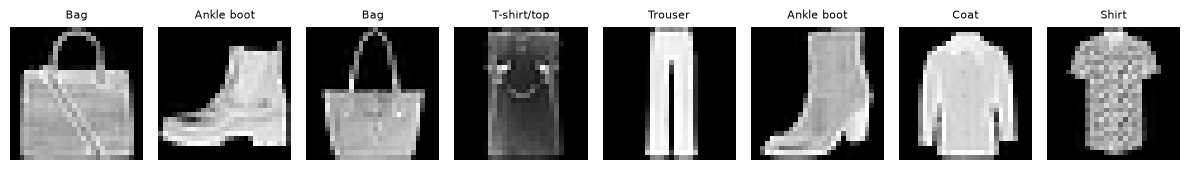

In [7]:
eda_ds = FashionMNISTView(train_full, train_idx, mean, std, mode='image', augment=False)
xb, yb = next(iter(DataLoader(eda_ds, batch_size=8, shuffle=False, num_workers=0)))
print(f'Processed batch: x shape={tuple(xb.shape)}, dtype={xb.dtype}; y shape={tuple(yb.shape)}, dtype={yb.dtype}')
print(f'Batch normalized pixel range: {xb.min().item():.3f} to {xb.max().item():.3f}')
print(f'Batch labels: {yb.tolist()}')
for mode in ['flatten', 'image', 'row_seq', 'col_seq', 'patch_seq']:
    print(f'{mode}: {tuple(to_representation(xb[0], mode=mode, patch_size=4).shape)}')

fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i, ax in enumerate(axes):
    ax.imshow((xb[i, 0] * std + mean).clamp(0, 1), cmap='gray', vmin=0, vmax=1)
    ax.set_title(class_names[yb[i].item()], fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

## EDA findings for the report

- **Problem/input:** one 28 × 28 grayscale article image is classified into one of 10 categories. The raw images are `uint8` with intensities from 0 to 255; `ToTensor` produces one-channel `float32` tensors.
- **Source/split:** Fashion-MNIST official 60,000 training and 10,000 test images. With seed 42 and a stratified 90/10 split of official training data, the working partitions are **54,000 train / 6,000 validation / 10,000 test**. Every class has **5,400 / 600** images in the training and validation subsets; test labels are not inspected in M1.
- **Balance:** the max/min class-count ratio is **1.000** in both inspected subsets and each class is **10%** of each subset. Class weighting is not indicated by frequency alone.
- **Pixel distribution:** training pixels have raw mean **72.98/255** and standard deviation **90.06/255**; **50.2%** are zero. No training image is entirely zero. The training-only normalization constants on the 0–1 scale are **mean 0.286209, standard deviation 0.353160**.
- **Class differences:** mean per-image brightness ranges from about **34.9** for sandals to **98.1** for coats; foreground coverage also differs by class. The boxplots and average images show useful variation and silhouettes. They suggest hypotheses for later model analysis, but do not establish which features a trained model uses.
- **Leakage controls:** train and validation indices are disjoint; the official test split remains separate. The exact raw-image hash audit found **0 shared image hashes** across train/validation. Normalization is estimated only from training examples. Exact hashes cannot rule out near duplicates or related products.
- **Preprocessing and representations:** `ToTensor`, training-only mean/std, and optional training-only flip/rotation. A processed batch has shape **(8, 1, 28, 28)**. The M1 input shape is **(784,)** after flattening. Utility modes for later models have shapes **(1, 28, 28)** for images, **(28, 28)** for row/column sequences, and **(49, 16)** for 4 × 4 patches; they are not used in M1 training.
- **Limits:** 28 × 28 grayscale images lose color and fine details; some garment categories have similar shapes. These observations motivate later confusion-matrix and failure-case analysis. EDA alone cannot establish model performance or real-world generalization.

**For the final report:** record dataset file checksums, exact training hardware/software versions, and model results only after running those experiments. The handbook requires AI-use disclosure in the report, assignment page, and `AI_USAGE.md`; the group must finish the verification fields in that log.

## 7. M1 Linear and MLP training and validation

Both models use the same cached stratified split, training-only normalization, batch size, optimizer, learning rate, and 10-epoch budget from `configs/m1.json`. Checkpoints are selected by lowest validation loss. This section reports validation results only; the official test set stays held out. Matching command-line runs are verified and reused, while a fresh notebook run trains both models.

In [8]:
from a1.train import run_experiment

m1_results = {
    name: run_experiment(name, "configs/m1.json", reuse_existing=True)
    for name in ("linear", "mlp")
}
comparison = pd.DataFrame([
    {
        "Model": name,
        "Best epoch": result["best_epoch"],
        "Validation loss": result["best_val_loss"],
        "Validation accuracy": result["best_val_accuracy"],
        "Validation macro-F1": result["best_val_macro_f1"],
        "Parameters": result["parameters"],
        "Training seconds": result["training_seconds"],
        "Device": result["device"],
    }
    for name, result in m1_results.items()
])
display(comparison.round(4))


,Model,Best epoch,Validation loss,Validation accuracy,Validation macro-F1,Parameters,Training seconds,Device
0,linear,9,0.3932,0.8648,0.8641,7850,27.5624,mps
1,mlp,8,0.2825,0.8987,0.8985,235146,28.1383,mps


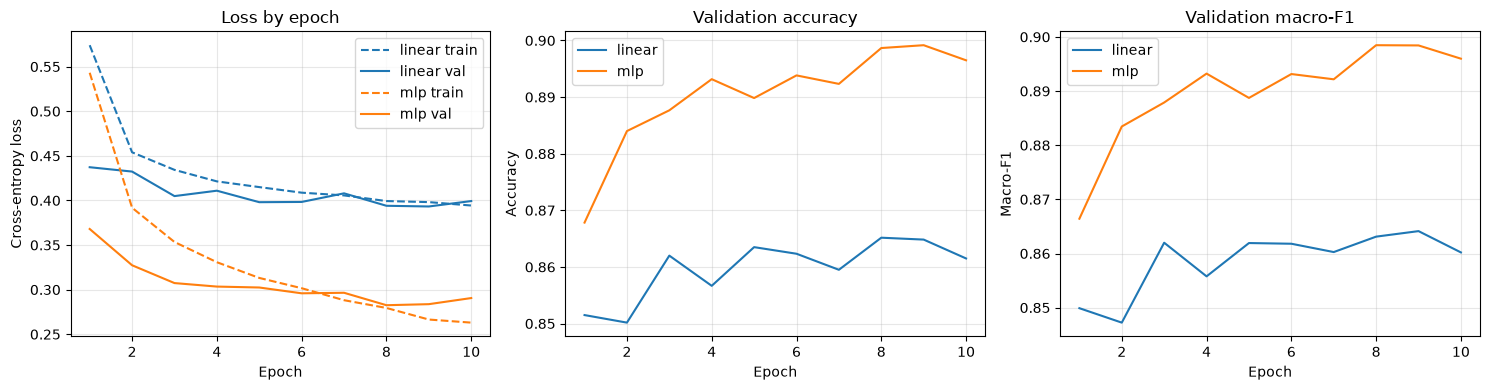

Best checkpoints were selected by validation loss. Validation metrics describe M1 progress, not held-out test performance.


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = {"linear": "tab:blue", "mlp": "tab:orange"}
for name, result in m1_results.items():
    history = pd.read_csv(result["history"])
    color = colors[name]
    axes[0].plot(history["epoch"], history["train_loss"], color=color, linestyle="--", label=f"{name} train")
    axes[0].plot(history["epoch"], history["val_loss"], color=color, label=f"{name} val")
    axes[1].plot(history["epoch"], history["val_accuracy"], color=color, label=name)
    axes[2].plot(history["epoch"], history["val_macro_f1"], color=color, label=name)
axes[0].set(title="Loss by epoch", xlabel="Epoch", ylabel="Cross-entropy loss")
axes[1].set(title="Validation accuracy", xlabel="Epoch", ylabel="Accuracy")
axes[2].set(title="Validation macro-F1", xlabel="Epoch", ylabel="Macro-F1")
for ax in axes:
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Best checkpoints were selected by validation loss. Validation metrics describe M1 progress, not held-out test performance.")
